In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA

df_schools = pd.read_csv('schools_data.csv')

features = [
    'P1_demand', 'P2A_demand', 'P2B_demand', 'P2C_demand', 'P2CS_demand',
    'top_psle_score', 'affiliation_count', 'gifted_ind', 'autonomous_ind', 'sap_ind',
    'subject_count', 'distprog_count',
    'cca_clubs', 'cca_sports', 'cca_uniformed', 'cca_arts'
]

# Fill NaN with 0
df_schools[features] = df_schools[features].fillna(0)

# Normalise
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_schools[features]), columns=features)

# PCA
pca = PCA()
pca.fit(df_scaled)


PCA()

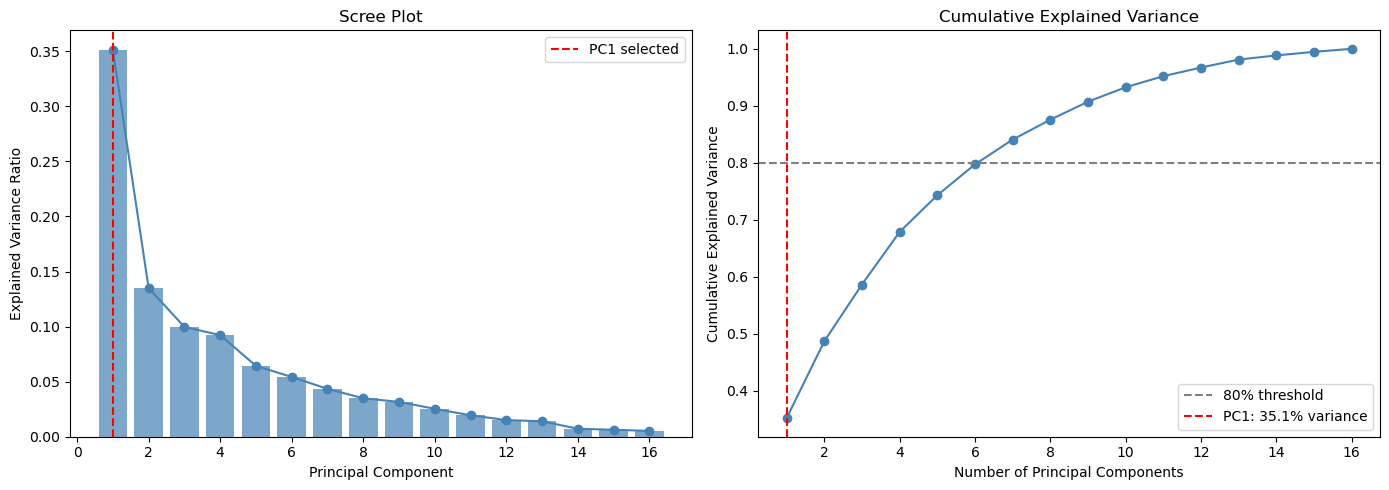

PC1 explains 35.1% of variance
PC1 + PC2 explains 48.7% of variance
PCs needed for 80% variance: 7


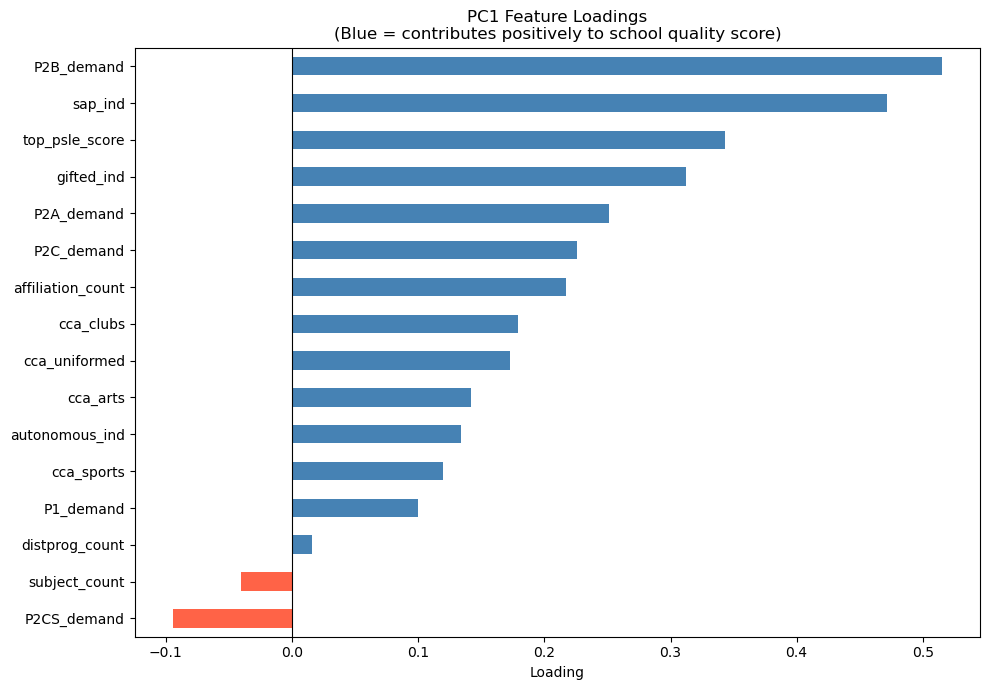

In [3]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# 1. Scree Plot + Cumulative Variance
explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].bar(range(1, len(explained_var)+1), explained_var, color='steelblue', alpha=0.7)
axes[0].plot(range(1, len(explained_var)+1), explained_var, 'o-', color='steelblue')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Scree Plot')
axes[0].axvline(x=1, color='red', linestyle='--', label='PC1 selected')
axes[0].legend()

# Cumulative variance
axes[1].plot(range(1, len(cumulative_var)+1), cumulative_var, 'o-', color='steelblue')
axes[1].axhline(y=0.80, color='gray', linestyle='--', label='80% threshold')
axes[1].axvline(x=1, color='red', linestyle='--', label=f'PC1: {explained_var[0]:.1%} variance')
axes[1].set_xlabel('Number of Principal Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend()

plt.tight_layout()
plt.savefig('pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"PC1 explains {explained_var[0]:.1%} of variance")
print(f"PC1 + PC2 explains {cumulative_var[1]:.1%} of variance")
print(f"PCs needed for 80% variance: {next(i+1 for i, v in enumerate(cumulative_var) if v >= 0.8)}")

# 2. PC1 Loadings Bar Chart
loadings_pc1 = pd.Series(pca.components_[0], index=features).sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['tomato' if x < 0 else 'steelblue' for x in loadings_pc1]
loadings_pc1.plot(kind='barh', color=colors, ax=ax)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('PC1 Feature Loadings\n(Blue = contributes positively to school quality score)')
ax.set_xlabel('Loading')
plt.tight_layout()
plt.savefig('pc1_loadings.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
# Use PC1 as school score
df_schools['school_score_raw'] = pca.transform(df_scaled)[:, 0]

# Standardise (z-score) the school scores
from sklearn.preprocessing import StandardScaler
score_scaler = StandardScaler()
df_schools['school_score'] = score_scaler.fit_transform(df_schools[['school_score_raw']])
mean = df_schools['school_score'].mean()
std = df_schools['school_score'].std()

def assign_tier(score):
    if score >= mean + std:
        return 'Tier 1'
    elif score < mean + std and score >= mean:
        return 'Tier 2'
    elif mean - 0.5 * std <= score and score < mean:
        return 'Tier 3'
    else:
        return 'Tier 4'

df_schools['school_tier'] = df_schools['school_score'].apply(assign_tier)

df_schools = df_schools.sort_values('school_score', ascending=False)
df_schools.to_csv('schools_tiered_withscores.csv', index=False)

#remove raw school scores
df_schools = df_schools.drop(columns=['school_score_raw'])
df_schools.to_csv('../cleaned_datasets/schools_tiered.csv', index=False)

print(df_schools[['school_name', 'school_score', 'school_tier']])
print(df_schools['school_tier'].value_counts().sort_index())

                         school_name  school_score school_tier
94            NANYANG PRIMARY SCHOOL      4.199362      Tier 1
22              CATHOLIC HIGH SCHOOL      4.148977      Tier 1
32   CHIJ ST. NICHOLAS GIRLS' SCHOOL      3.871867      Tier 1
152                   TAO NAN SCHOOL      3.066495      Tier 1
93            NAN HUA PRIMARY SCHOOL      2.960970      Tier 1
..                               ...           ...         ...
44          EDGEFIELD PRIMARY SCHOOL     -0.815958      Tier 4
181          ZHONGHUA PRIMARY SCHOOL     -0.816120      Tier 4
114           PIONEER PRIMARY SCHOOL     -0.830745      Tier 4
12          BENDEMEER PRIMARY SCHOOL     -0.837486      Tier 4
102         NORTHOAKS PRIMARY SCHOOL     -0.963968      Tier 4

[182 rows x 3 columns]
school_tier
Tier 1    23
Tier 2    31
Tier 3    60
Tier 4    68
Name: count, dtype: int64
